### Validate that the correct cluster IDs are assigned to each rechit.
* Compare the cluster level eta and phi to the individual rechits

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import uproot
from datetime import datetime
import plotly.graph_objects as go

In [20]:

DATA_FILE = '/uscms/home/tlee/nobackup/work/mds-ml/data/MuonSystem_Tree.root'
OUTPUT_DIR = '/uscms/home/tlee/nobackup/work/mds-ml/notebooks/validate_cluster_id/images'
TIMESTAMP = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

root_file = uproot.open(DATA_FILE)
tree = root_file['MuonSystem']

event_num = tree['evtNum'].array(library='np')
lumi_section = tree['lumiSec'].array(library='np')
run_num = tree['runNum'].array(library='np')

csc_phi = tree['CscRechitsPhi'].array(library='np')
csc_eta = tree['CscRechitsEta'].array(library='np')
csc_id = tree['CscRechitsClusterId'].array(library='np')

csc_cluster_phi = tree['cscRechitClusterPhi'].array(library='np')
csc_cluster_eta = tree['cscRechitClusterEta'].array(library='np')

dt_phi = tree['DtRechitsPhi'].array(library='np')
dt_eta = tree['DtRechitsEta'].array(library='np')
dt_id = tree['DtRechitsClusterId'].array(library='np')

dt_cluster_phi = tree['dtRechitClusterPhi'].array(library='np')
dt_cluster_eta = tree['dtRechitClusterEta'].array(library='np')

print(f"csc_cluster_phi: {csc_cluster_phi}")
print(f"csc_cluster_eta: {csc_cluster_eta}")
print(f"csc_id: {csc_id}")
print(f"csc_phi: {csc_phi}")
print(f"csc_eta: {csc_eta}")


csc_cluster_phi: [array([-2.5509007, -2.517585 , -2.58877  ], dtype=float32)
 array([2.9318864, 2.9287746, 2.9282513], dtype=float32)]
csc_cluster_eta: [array([-2.1865191, -1.9870874, -1.7799633], dtype=float32)
 array([-2.4029193, -2.1803327, -1.8212696], dtype=float32)]
csc_id: [array([-1, -1, -1, ...,  0,  0,  0], shape=(1223,), dtype=int32)
 array([-1, -1, -1, -1, -1, -1,  2,  2,  2,  0,  0,  0,  1,  2,  2,  2,  0,
         0,  0,  1,  2,  2,  2,  0,  0,  0,  1,  2,  2,  2,  0,  0,  0,  1,
         2,  2,  2,  0,  0,  0,  1,  2,  2,  2,  0,  0,  0,  1,  2,  2,  2,
         0,  0,  0,  1,  2,  2,  2,  0,  0,  0,  1,  2,  2,  2,  0,  0,  0,
         1,  2,  2,  2,  2,  0,  0,  0,  1,  2,  2,  2,  2,  0,  0,  0,  1,
         2,  2,  2,  2,  0,  0,  0,  1,  2,  2,  2,  2,  0,  0,  0,  1,  2,
         2,  2,  2,  0,  0,  0,  1,  2,  2,  2,  2,  0,  0,  0,  1,  2,  2,
         2,  2,  0,  0,  0,  1,  2,  2,  2,  2,  0,  0,  0,  1,  2,  2,  2,
         0,  0,  1,  2,  2,  2,  0,  0,  1,  

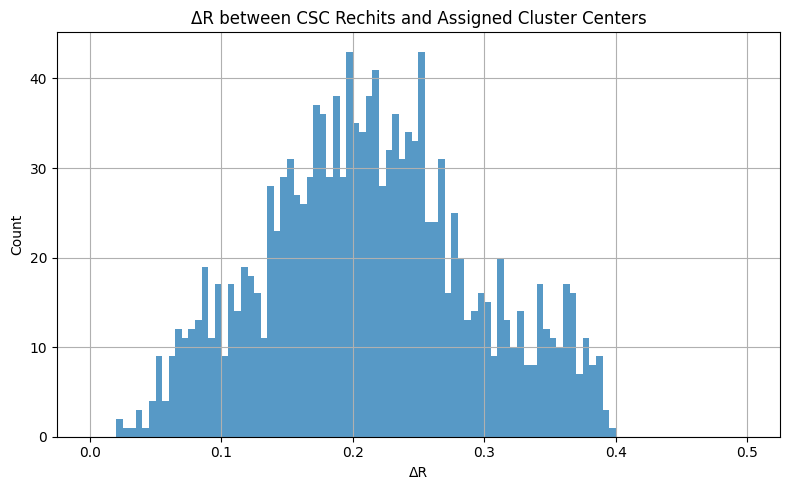

ΔR: mean = 0.2560, std = 0.1408, max = 0.6331


In [21]:

def delta_phi(phi1, phi2):
    """Wrap-around-safe phi difference."""
    dphi = phi1 - phi2
    return (dphi + np.pi) % (2 * np.pi) - np.pi

delta_r_list = []

for i in range(len(csc_phi)):
    for j in range(len(csc_phi[i])):
        cluster_id = csc_id[i][j]
        if cluster_id >= 0 and cluster_id < len(csc_cluster_phi[i]):
            rechit_phi = csc_phi[i][j]
            rechit_eta = csc_eta[i][j]
            cluster_phi = csc_cluster_phi[i][cluster_id]
            cluster_eta = csc_cluster_eta[i][cluster_id]

            dphi = delta_phi(rechit_phi, cluster_phi)
            deta = rechit_eta - cluster_eta
            delta_r = np.sqrt(dphi**2 + deta**2)

            delta_r_list.append(delta_r)

# Plot histogram of ΔR
plt.figure(figsize=(8, 5))
plt.hist(delta_r_list, bins=100, range=(0, 0.5), alpha=0.75, label='ΔR')
plt.xlabel('ΔR')
plt.ylabel('Count')
plt.title('ΔR between CSC Rechits and Assigned Cluster Centers')
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{TIMESTAMP}_csc_rechit_cluster_deltaR.png")
plt.show()

# Optional stats
print(f"ΔR: mean = {np.mean(delta_r_list):.4f}, std = {np.std(delta_r_list):.4f}, max = {np.max(delta_r_list):.4f}")
